#Short Term Electrical Load Forecasting using LSTM in PyTorch



## Objective

Develop a LSTM neutral network using ytorch to Predict next hour's electrical load electricity using previous 24 hours electrical load data from PJM Hourly Energy Consumption dataset.



Import Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

Load Dataset

In [32]:

df = pd.read_csv('PJME_hourly.csv')
df = df.iloc[:20000]
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


Preprocess Data

In [33]:
print(df.shape)

(20000, 2)


In [34]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  20000 non-null  object 
 1   PJME_MW   20000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 312.6+ KB


In [36]:
df.describe()

,PJME_MW
count,20000.000000
mean,31456.425400
std,6173.949745
min,19247.000000
25%,27033.000000
50%,31184.000000
75%,34746.000000
max,55934.000000


In [37]:
print(df.isnull().sum())

Datetime    0
PJME_MW     0
dtype: int64


In [38]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [39]:
df = df.set_index('Datetime')

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['PJME_MW'] = scaler.fit_transform(
    df[['PJME_MW']]
)


Data Visualization

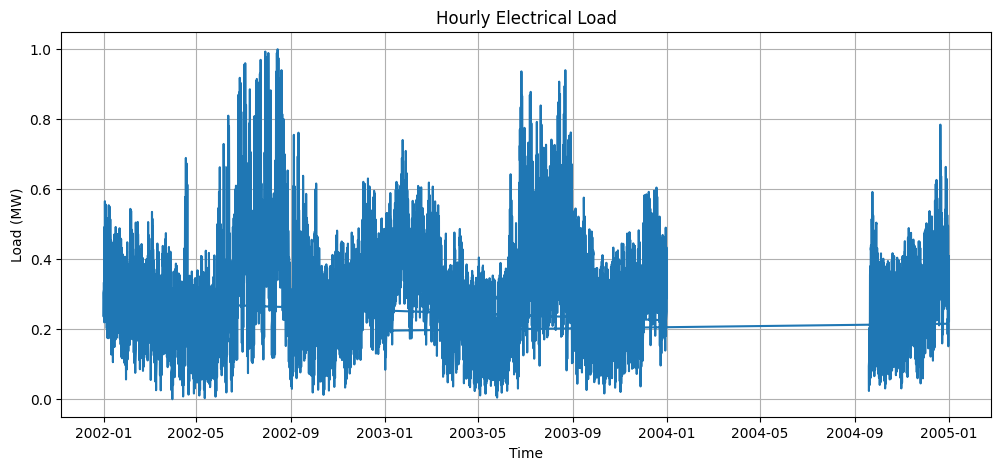

In [41]:
plt.figure(figsize=(12,5))
plt.plot(df['PJME_MW'])
plt.title("Hourly Electrical Load")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

Create Sequences

In [42]:
def create_sequence(data,seq_len):
  X = []
  y = []

  for i in range(len(data)-seq_len):
    X.append(data[i:i+seq_len])
    y.append(data[i+seq_len])

  return np.array(X),np.array(y)

In [43]:
SEQ_LEN = 24
X,y = create_sequence(
    df['PJME_MW'].values,SEQ_LEN
)

Train Test Split

In [44]:
split = int(0.8*len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Convert to Tensors

In [45]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)


y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [46]:
X_train = X_train.unsqueeze(-1)
X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(-1)

Create Dataloader

In [47]:
train_dataset = TensorDataset(X_train,y_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

LSTM Model

In [48]:
class LSTMModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.lstm = nn.LSTM(
        input_size = 1,
        hidden_size = 64,
        num_layers = 2,
        batch_first = True
    )
    self.fc = nn.Linear(64,1)

  def forward(self,x):
    out,_ = self.lstm(x)
    out = out[:,-1,:]
    out = self.fc(out)

    return out

Loss & Optimizer

In [49]:
criterion = nn.MSELoss()

In [50]:
model = LSTMModel()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Train the Model

In [51]:
for epoch in range(50):
  epoch_loss = 0
  for X_batch, y_batch in train_loader:
    output = model(X_batch)
    loss = criterion(output.squeeze(),y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
  print(f"Epoch{epoch+1}/50 - Loss: {epoch_loss/len(train_loader):.6f}")

Epoch1/50 - Loss: 0.023907
Epoch2/50 - Loss: 0.007037
Epoch3/50 - Loss: 0.002741
Epoch4/50 - Loss: 0.001520
Epoch5/50 - Loss: 0.001009
Epoch6/50 - Loss: 0.000858
Epoch7/50 - Loss: 0.000824
Epoch8/50 - Loss: 0.000810
Epoch9/50 - Loss: 0.000806
Epoch10/50 - Loss: 0.000805
Epoch11/50 - Loss: 0.000798
Epoch12/50 - Loss: 0.000770
Epoch13/50 - Loss: 0.000723
Epoch14/50 - Loss: 0.000658
Epoch15/50 - Loss: 0.000541
Epoch16/50 - Loss: 0.000489
Epoch17/50 - Loss: 0.000478
Epoch18/50 - Loss: 0.000459
Epoch19/50 - Loss: 0.000448
Epoch20/50 - Loss: 0.000441
Epoch21/50 - Loss: 0.000438
Epoch22/50 - Loss: 0.000435
Epoch23/50 - Loss: 0.000433
Epoch24/50 - Loss: 0.000431
Epoch25/50 - Loss: 0.000427
Epoch26/50 - Loss: 0.000424
Epoch27/50 - Loss: 0.000420
Epoch28/50 - Loss: 0.000416
Epoch29/50 - Loss: 0.000412
Epoch30/50 - Loss: 0.000409
Epoch31/50 - Loss: 0.000406
Epoch32/50 - Loss: 0.000403
Epoch33/50 - Loss: 0.000400
Epoch34/50 - Loss: 0.000397
Epoch35/50 - Loss: 0.000394
Epoch36/50 - Loss: 0.000391
E

Model Evaluation

In [52]:
model.eval()

with torch.no_grad():

    pred = model(X_test)

In [53]:
pred = scaler.inverse_transform(
    pred.numpy()
)

actual=scaler.inverse_transform(
    y_test.reshape(-1,1)
)

Performance Metrics

In [54]:
mae = mean_absolute_error(
    actual,
    pred
)

print(mae)

483.8805737537201


In [55]:
rmse = np.sqrt(mean_squared_error(actual,pred))
print("RMSE:",rmse)

RMSE: 721.7677238357797


Visualization of Results

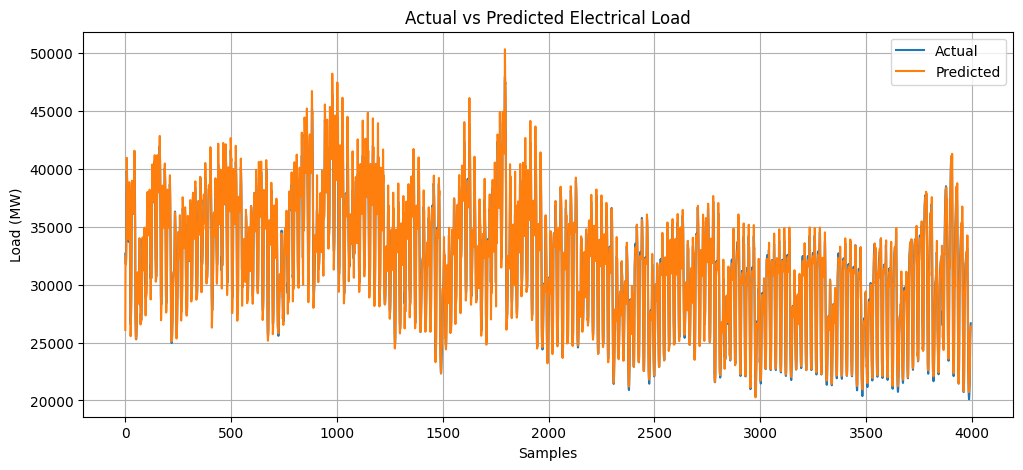

In [56]:
plt.figure(figsize=(12,5))
plt.plot(actual,label='Actual')

plt.plot(pred,label='Predicted')
plt.title("Actual vs Predicted Electrical Load")
plt.xlabel("Samples")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True)
plt.show()

Next hour Load Prediction

In [57]:
last_sequence = df['PJME_MW'].values[-SEQ_LEN:]

input_data = torch.tensor(last_sequence, dtype=torch.float32)
input_data = input_data.unsqueeze(0).unsqueeze(-1) # Shape becomes (1, SEQ_LEN, 1)

model.eval()

with torch.no_grad():
  prediction = model(input_data)

prediction = scaler.inverse_transform(prediction.numpy())
print("Predicted next-hour load:", prediction[0][0],"MW")

Predicted next-hour load: 26411.291 MW


#Conclusion

The LTSM model Successfully predicts the next hour's electrical load using the previous 24 hours of historical load data. The model achieved satisfactory performance based on MAE and RMSE values.